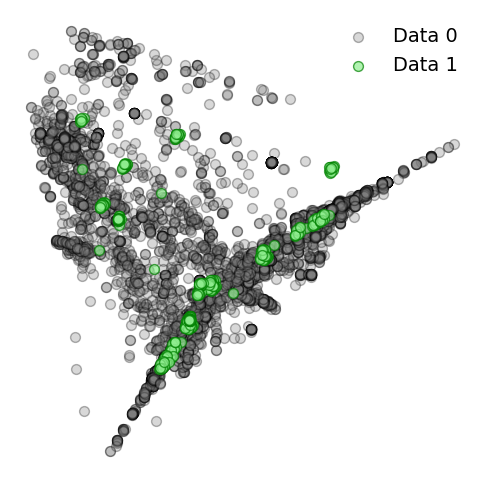

In [1]:
# === Chemical Space Comparison: Dataset 1 vs Dataset 2 ===
import pandas as pd
import numpy as np
import json
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pymatgen.core import Composition

# ===============================
# Load both datasets
# ===============================
df1 = pd.read_csv("./data/mxene_mp.csv")     # Dataset 1 (MP-like)
df2 = pd.read_csv("./data/mxene_real.csv")   # Dataset 2 (real MXenes)

# ===============================
# Parse Dataset 1 composition (JSON dict)
# ===============================
def parse_comp_dict_json(comp_str):
    try:
        d = json.loads(comp_str)
        tot = sum(d.values())
        return {el: float(n)/tot for el, n in d.items()}
    except:
        return {}

df1["comp_dict"] = df1["composition"].apply(parse_comp_dict_json)

# ===============================
# Parse Dataset 2 MXene formula using pymatgen
# ===============================
def parse_formula_to_fraction(formula):
    try:
        comp = Composition(formula).as_dict()
        total = sum(comp.values())
        return {el: float(n)/total for el, n in comp.items()}
    except:
        return {}

df2["comp_dict"] = df2["mxene"].apply(parse_formula_to_fraction)

# ===============================
# Build unified element list (top-N elements across BOTH datasets)
# ===============================
element_counts = {}

for comp in pd.concat([df1["comp_dict"], df2["comp_dict"]]):
    for el in comp:
        element_counts[el] = element_counts.get(el, 0) + 1

# Sort by frequency
sorted_elems = sorted(element_counts.keys(), key=lambda x: element_counts[x], reverse=True)

TOPN = 50
top_elements = sorted_elems[:TOPN]

# ===============================
# Convert comp_dict → vector
# ===============================
def comp_to_vec(comp_dict, elems):
    return [comp_dict.get(el, 0.0) for el in elems]

X1 = np.array([comp_to_vec(cd, top_elements) for cd in df1["comp_dict"]])
X2 = np.array([comp_to_vec(cd, top_elements) for cd in df2["comp_dict"]])

# ===============================
# Joint PCA
# ===============================
X_all = np.vstack([X1, X2])
pca = PCA(n_components=2, random_state=0)
Z_all = pca.fit_transform(X_all)

Z1 = Z_all[:len(df1)]
Z2 = Z_all[len(df1):]

# ===============================
# Visualization (your style)
# ===============================
plt.figure(figsize=(6, 6))

# Dataset 1 (large MP-like set)
plt.scatter(
    Z1[:, 0], Z1[:, 1],
    c="gray", edgecolor="black",
    s=50, alpha=0.30,
    label="Data 0"
)

# Dataset 2 (real MXenes)
plt.scatter(
    Z2[:, 0], Z2[:, 1],
    c="lightgreen", edgecolor="green",
    s=50, alpha=0.70,
    label="Data 1"
)

# Remove axes, ticks, labels, and frame
plt.xticks([])
plt.yticks([])
plt.xlabel("")
plt.ylabel("")
plt.box(False)

plt.legend(frameon=False, fontsize=14)

plt.savefig("./visual/fig1f.jpg", dpi=500, bbox_inches="tight")
plt.show()
